In [1]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.SINDyModel import *
from src.derivatives import *
from src.helpers import *
from src.experiments import *

import matplotlib.pyplot as plt
from tqdm import tqdm

# Lotka-Volterra

In [2]:
lotka_volterra_rhs = generate_lotka_volterra_rhs(1, 0.1, 1.5, 0.75)
true_coeffs = generate_lotka_volterra_true_coefficients(1, 0.1, 1.5, 0.75)

dts = np.logspace(-2, 0, 11).tolist()
noise_levels = np.logspace(-3, 0, 10).tolist()

t_span = (0, 50)

# if a parameter is a list, the experiment will be run for each combination of the parameters
# if a parameter is not a list, the same value will be used for all experiments
# the first list will be the rows and the second list will be the columns
experiment_config = {
    # define fixed parameters
    'rhs': lotka_volterra_rhs,
    'derivative_approximation': dxdt_finite_difference,
    't_eval_test': np.arange(t_span[0], t_span[1] + 0.01, 0.01),
    # define parameters that can be lists
    'x0': (10, 5),
    'noise_level': noise_levels,
    't_eval_train': None, 'dt': dts, 't_span': t_span, # we can use one of "t_eval_train" or ("dt" and "t_span")
    'threshold': 0.05,
    # define parameters that are used after the experiment
    'true_coeffs': true_coeffs
}

results = run_experiment(experiment_config)

rows are noise_level. there are 10 rows.
columns are dt. there are 11 columns.
step 1 of 10


 73%|███████▎  | 8/11 [00:06<00:02,  1.41it/s]c:\Users\Elliot\anaconda3\envs\ds312\Lib\site-packages\scipy\integrate\_ivp\lsoda.py:161: UserWarning: lsoda: Repeated error test failures (internal error).
  solver._y, solver.t = integrator.run(
100%|██████████| 11/11 [00:10<00:00,  1.08it/s]


step 2 of 10


 45%|████▌     | 5/11 [00:04<00:05,  1.13it/s]c:\Elliot\docs\education\college\2024-2025\MS project\MS-project\src\SINDyModel.py:9: RuntimeWarning: overflow encountered in power
  return lambda x: np.prod(np.power(x, power_tuple), axis=1)
c:\Elliot\docs\education\college\2024-2025\MS project\MS-project\src\SINDyModel.py:142: RuntimeWarning: invalid value encountered in matmul
  x_dot = Theta @ self.Xi
c:\Users\Elliot\anaconda3\envs\ds312\Lib\site-packages\scipy\integrate\_ivp\lsoda.py:161: UserWarning: lsoda: Excess accuracy requested (tolerances too small).
  solver._y, solver.t = integrator.run(
100%|██████████| 11/11 [00:13<00:00,  1.21s/it]


step 3 of 10


...

 82%|████████▏ | 9/11 [00:16<00:03,  1.97s/it]c:\Users\Elliot\anaconda3\envs\ds312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
100%|██████████| 11/11 [00:20<00:00,  1.88s/it]


step 9 of 10


100%|██████████| 11/11 [00:07<00:00,  1.57it/s]


step 10 of 10


100%|██████████| 11/11 [00:06<00:00,  1.58it/s]


rows are noise_level. there are 10 rows.
columns are dt. there are 11 columns.


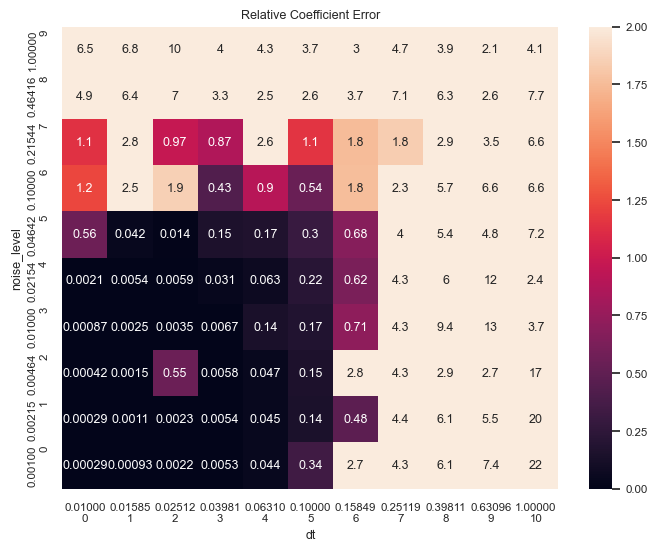

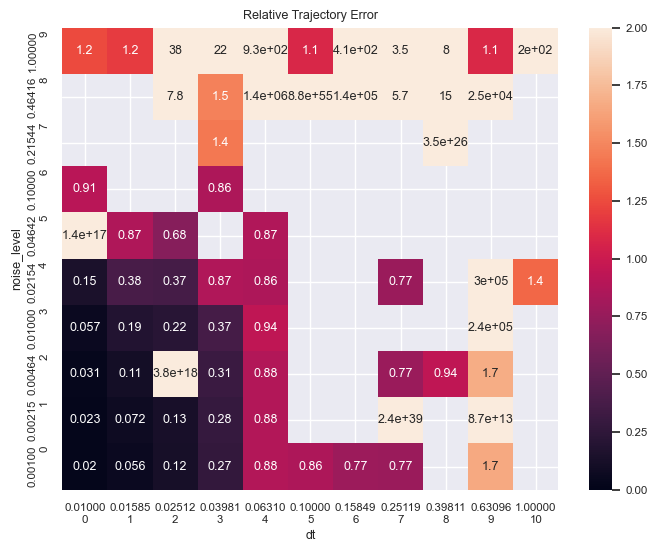

In [3]:
plot_heatmaps(experiment_config, results)

x0' = + 0.99056 x0 + -0.09927 x0 x1 
x1' = + -1.49204 x1 + 0.74543 x0 x1 


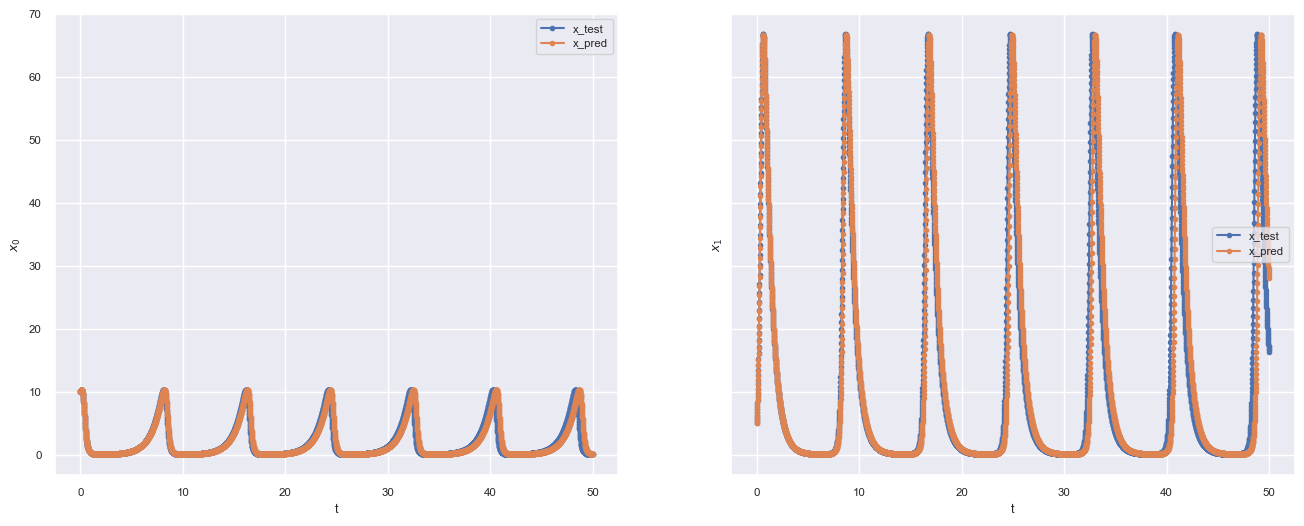

In [4]:
display_single_result(experiment_config, results, 3, 3)

In [5]:
# # look at how well SINDy can predict the derivative if we know the true trajectory

# col = 2
# row = 4

# # extract the relevant data from results
# result = results[row][col]
# # extract the relevant data from the result
# t_eval = result['t_eval_train']
# x_train = result['x_train']
# x_dot_true = lotka_volterra_rhs(0, x_train)
# x_dot_pred = result['model'].predict(x_train)

# n_state_vars = x_dot_true.shape[0]

# # plot the training data and model prediction
# fig, axs = plt.subplots(1, n_state_vars, figsize=(16, 6))

# for sv in range(n_state_vars):
#     axs[sv].plot(t_eval, x_dot_true[sv], "r.-", label="$x'_{true}$")
#     axs[sv].plot(t_eval, x_dot_pred[sv], "k.-", label="$x'_{pred}$")

#     # set labels
#     axs[sv].set_xlabel("t")
#     axs[sv].set_ylabel(f"$x'_{sv}$")
#     axs[sv].legend()

# Van der Pol

In [6]:
van_der_pol_rhs = generate_van_der_pol_rhs(0.1)
true_coeffs = generate_van_der_pol_true_coefficients(0.1)

dts = np.logspace(-2, 0, 11).tolist()
noise_levels = np.logspace(-3, 0, 10).tolist()

t_span = (0, 50)

# if a parameter is a list, the experiment will be run for each combination of the parameters
# if a parameter is not a list, the same value will be used for all experiments
# the first list will be the rows and the second list will be the columns
experiment_config2 = {
    # define fixed parameters
    'rhs': van_der_pol_rhs,
    'derivative_approximation': dxdt_finite_difference,
    't_eval_test': np.arange(t_span[0], t_span[1] + 0.01, 0.01),
    # define parameters that can be lists
    'x0': (10, 5),
    'noise_level': noise_levels,
    't_eval_train': None, 'dt': dts, 't_span': t_span, # we can use one of "t_eval_train" or ("dt" and "t_span")
    'threshold': 0.05,
    # define parameters that are used after the experiment
    'true_coeffs': true_coeffs
}

results2 = run_experiment(experiment_config)

rows are noise_level. there are 10 rows.
columns are dt. there are 11 columns.
step 1 of 10


 73%|███████▎  | 8/11 [00:09<00:02,  1.02it/s]c:\Users\Elliot\anaconda3\envs\ds312\Lib\site-packages\scipy\integrate\_ivp\lsoda.py:161: UserWarning: lsoda: Repeated error test failures (internal error).
  solver._y, solver.t = integrator.run(
100%|██████████| 11/11 [00:13<00:00,  1.27s/it]


step 2 of 10


 45%|████▌     | 5/11 [00:04<00:04,  1.21it/s]c:\Elliot\docs\education\college\2024-2025\MS project\MS-project\src\SINDyModel.py:9: RuntimeWarning: overflow encountered in power
  return lambda x: np.prod(np.power(x, power_tuple), axis=1)
c:\Elliot\docs\education\college\2024-2025\MS project\MS-project\src\SINDyModel.py:142: RuntimeWarning: invalid value encountered in matmul
  x_dot = Theta @ self.Xi
c:\Users\Elliot\anaconda3\envs\ds312\Lib\site-packages\scipy\integrate\_ivp\lsoda.py:161: UserWarning: lsoda: Excess accuracy requested (tolerances too small).
  solver._y, solver.t = integrator.run(
100%|██████████| 11/11 [00:13<00:00,  1.23s/it]


step 3 of 10


...

 82%|████████▏ | 9/11 [00:12<00:02,  1.13s/it]c:\Users\Elliot\anaconda3\envs\ds312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
100%|██████████| 11/11 [00:15<00:00,  1.40s/it]


step 9 of 10


100%|██████████| 11/11 [00:06<00:00,  1.57it/s]


step 10 of 10


100%|██████████| 11/11 [00:03<00:00,  3.29it/s]


rows are noise_level. there are 10 rows.
columns are dt. there are 11 columns.


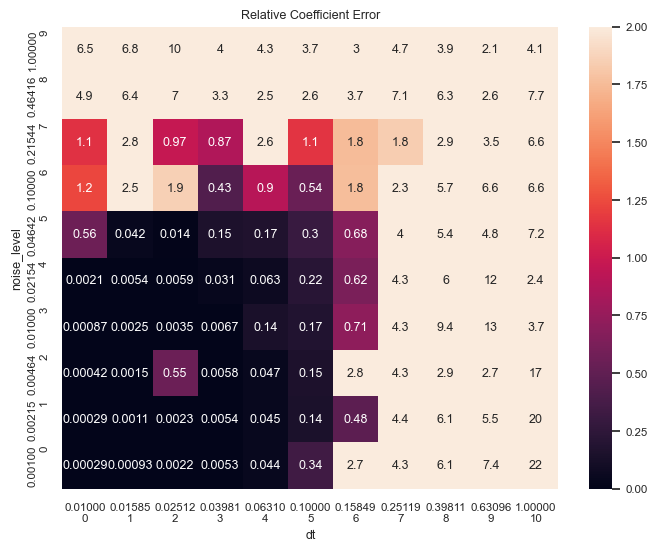

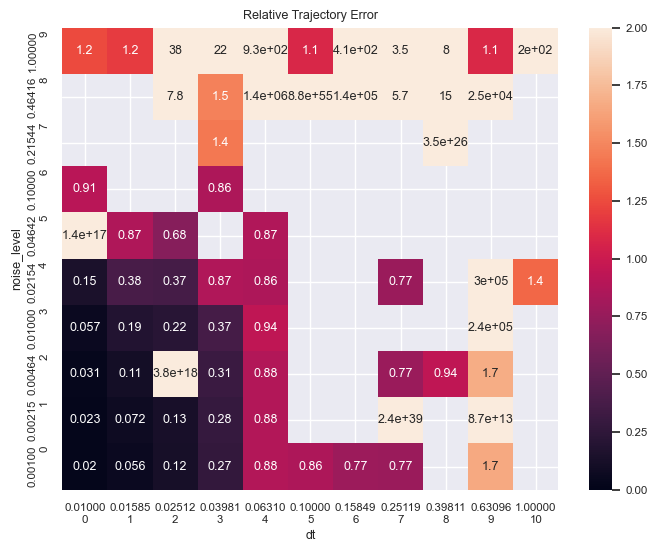

In [7]:
plot_heatmaps(experiment_config, results2)